# Data Cleaning Fundamentals: Building a Reproducible Data Cleaning Pipeline

In this notebook, we'll work through a complete data cleaning pipeline using a real-world dataset. Rather than discussing individual techniques in isolation, we'll apply them step by step to transform raw, messy data into a clean, analysis-ready dataset.

We'll use the **Global Layoffs** dataset, which contains information on company layoffs between **2020 and 2023**. The dataset includes many of the data quality issues commonly encountered in real projects, such as missing values, duplicate records, inconsistent text, formatting issues, and incorrect data types, making it an excellent example for practicing end-to-end data cleaning.

If you'd like to learn more about each data cleaning technique covered in this notebook, you can refer to the accompanying articles in the **Data Cleaning Fundamentals** series.

**Dataset:** `layoffs.csv`

**Source:** [Alex The Analyst GitHub Repository](https://github.com/AlexTheAnalyst/MySQL-YouTube-Series?utm_source=chatgpt.com)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load the Dataset

The first step in any data cleaning project is to load the dataset into a pandas DataFrame. Once loaded, we can begin exploring its structure and identifying potential data quality issues that need to be addressed.


In [2]:
df = pd.read_csv("layoffs.csv")

## Step 2: Inspect the Data

Before making any changes to the dataset, it's important to understand what we're working with. Data inspection provides an overview of the dataset's structure, including the available columns, data types, missing values, and basic statistics. This initial exploration helps us identify potential data quality issues and determine the cleaning steps required before moving on to analysis.


In [3]:
df.head()

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
0,Atlassian,Sydney,Other,500.0,0.05,3/6/2023,Post-IPO,Australia,210.0
1,SiriusXM,New York City,Media,475.0,0.08,3/6/2023,Post-IPO,United States,525.0
2,Alerzo,Ibadan,Retail,400.0,NaN,3/6/2023,Series B,Nigeria,16.0
3,UpGrad,Mumbai,Education,120.0,NaN,3/6/2023,Unknown,India,631.0
4,Loft,Sao Paulo,Real Estate,340.0,0.15,3/3/2023,Unknown,Brazil,788.0


The first five rows provide an initial glimpse of the dataset. Reviewing a small sample allows us to become familiar with the available columns, the type of information each column contains, and any obvious data quality issues, such as missing values, inconsistent formatting, or unexpected entries.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2361 entries, 0 to 2360
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company                2361 non-null   object 
 1   location               2361 non-null   object 
 2   industry               2357 non-null   object 
 3   total_laid_off         1621 non-null   float64
 4   percentage_laid_off    1576 non-null   float64
 5   date                   2360 non-null   object 
 6   stage                  2355 non-null   object 
 7   country                2361 non-null   object 
 8   funds_raised_millions  2152 non-null   float64
dtypes: float64(3), object(6)
memory usage: 166.1+ KB


This summary provides a quick overview of the dataset's structure. We can see that it contains **nine columns**, along with their corresponding data types and the number of non-null values in each column.

Notice that the non-null counts are not the same across all columns. This indicates that some columns contain missing (null) values, meaning not every record has information for every field. Identifying these missing values early is an important part of the data cleaning process, as it helps us determine which columns require further attention.


In [5]:
df.describe()

,total_laid_off,percentage_laid_off,funds_raised_millions
count,1621.000000,1576.000000,2152.000000
mean,238.358421,0.257917,822.454134
std,769.718801,0.255575,5593.961626
min,3.000000,0.000000,0.000000
25%,36.000000,0.100000,50.000000
50%,80.000000,0.170000,156.500000
75%,180.000000,0.300000,445.000000
max,12000.000000,1.000000,121900.000000


The descriptive statistics provide a summary of the numerical columns in the dataset. These statistics include the **count**, **mean**, **standard deviation**, **minimum**, **maximum**, and various percentile values.

Reviewing these metrics helps us better understand the distribution of the data and can reveal potential data quality issues. For example, unusually large or small values may indicate outliers, while differences between the **count** and the total number of rows suggest the presence of missing values in a column.


## Step 3: Handle Missing Values

In [6]:
df.isnull().sum()

,0
company,0
location,0
industry,4
total_laid_off,740
percentage_laid_off,785
date,1
stage,6
country,0
funds_raised_millions,209


The next step is to identify missing values in the dataset. The table below shows the number of missing values in each column. While some columns, such as **country**, contain no missing values, others have a substantial number of missing entries. Choosing an appropriate strategy for handling missing data depends on both the number of missing values and the role of the column in the analysis.

We'll use the following approach for each column:

* **industry:** This column contains only **4 missing values**. Since the number is very small, we'll remove these rows.
* **total_laid_off:** This numerical column has **740 missing values**. Rather than removing a large portion of the dataset, we'll impute the missing values.
* **percentage_laid_off:** This numerical column also contains a considerable number of missing values, so we'll impute them as well.
* **date:** There is only **1 missing value** in this column. We'll remove the corresponding row.
* **stage:** This column contains **6 missing values**. Because the number is small, we'll remove these rows.
* **funds_raised_millions:** This numerical column has **209 missing values**. Since removing these rows would result in a significant loss of data, we'll impute the missing values instead.

By tailoring our strategy to each column, we can preserve as much useful information as possible while maintaining the quality and reliability of the dataset.


In [7]:
# Missing values in industry, date and stage columns will be removed.

df.dropna(subset=['industry', 'date', 'stage'], inplace=True)

# Missing values in total_laid_off, percentage_laid_off and funds_raised_millions columns will be imputed.

df['total_laid_off'].fillna(df['total_laid_off'].mean(), inplace=True)
df['percentage_laid_off'].fillna(df['percentage_laid_off'].mean(), inplace=True)
df['funds_raised_millions'].fillna(df['funds_raised_millions'].mean(), inplace=True)

/tmp/ipykernel_1906/2081765036.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_laid_off'].fillna(df['total_laid_off'].mean(), inplace=True)
/tmp/ipykernel_1906/2081765036.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

## Step 4: Remove Duplicate Records

In [8]:
df.duplicated().sum()

np.int64(5)

Next, we check the dataset for duplicate records. The results show that the dataset contains **5 duplicate rows**. Because duplicate records can lead to inflated counts, biased statistics, and misleading analysis, we'll remove them to ensure that each observation appears only once in the dataset.


In [9]:
df = df.drop_duplicates()

## Step 5:  Fixing Data Types

In [10]:
df.dtypes

,0
company,object
location,object
industry,object
total_laid_off,float64
percentage_laid_off,float64
date,object
stage,object
country,object
funds_raised_millions,float64


Next, we review the data types of each column. Most of the columns already have appropriate data types for analysis. The only exception is the **date** column, which is currently stored as text (`object`). Converting it to the `datetime` data type will allow us to perform date-based operations more efficiently, such as extracting the year or month, filtering by date ranges, and conducting time-series analyses.


In [11]:
df["date"] = pd.to_datetime(
    df["date"]
)

## Step 6: Standardize Categories

The next step is to check for inconsistent formatting and categorical values that may require standardization. In this dataset, the text fields are already consistent, with no noticeable differences in capitalization, spelling, abbreviations, or formatting. As a result, no additional standardization is necessary, and we can proceed to the next stage of the cleaning process.


## Step 7: Detect and Investigate Outliers

The final step in our cleaning pipeline is to investigate potential outliers. Outliers are observations that differ substantially from the rest of the data and may result from data entry errors, measurement errors, or genuine but rare events. Rather than removing them automatically, it's important to examine whether they are valid observations and consider their potential impact on the analysis.

The box plots below summarize the distribution of the numerical columns in the dataset. We can observe several potential outliers in **total_laid_off**, **percentage_laid_off**, and **funds_raised_millions**. However, these values appear to represent legitimate business events, such as large-scale layoffs or companies with exceptionally high funding, rather than errors in the data. Since these observations reflect real-world phenomena and are meaningful for subsequent analysis, we'll retain them in the dataset.


<Axes: xlabel='total_laid_off'>

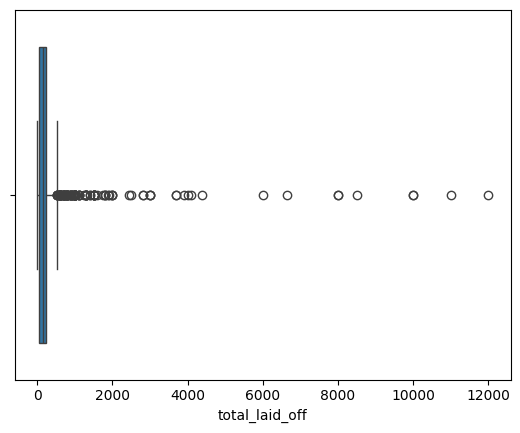

In [12]:
sns.boxplot(
    x=df["total_laid_off"]
)

<Axes: xlabel='percentage_laid_off'>

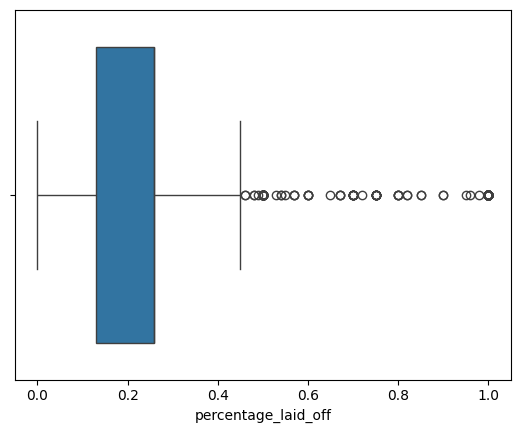

In [13]:
sns.boxplot(
    x=df["percentage_laid_off"]
)

<Axes: xlabel='funds_raised_millions'>

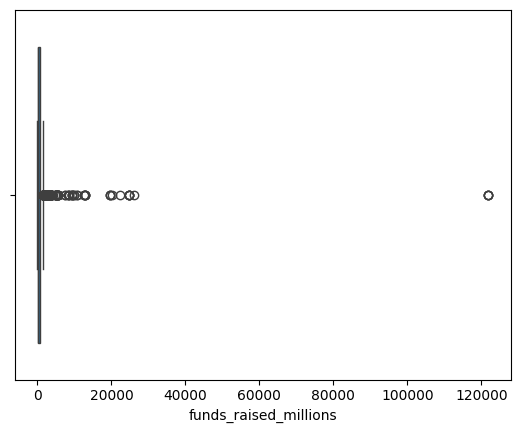

In [14]:
sns.boxplot(
    x=df["funds_raised_millions"]
)

## Step 8: Validate the Results

After completing all cleaning steps, it's important to validate the results to ensure the dataset is ready for analysis. Validation involves checking that missing values have been handled appropriately, duplicate records have been removed, data types are correct, and no unintended changes were introduced during the cleaning process.

In this notebook, we'll perform a final review of the dataset by examining its structure, data types, missing values, and summary statistics. This final validation step gives us confidence that the data is clean, consistent, and suitable for downstream tasks such as exploratory data analysis, visualization, and machine learning.


In [15]:
df.describe()

,total_laid_off,percentage_laid_off,date,funds_raised_millions
count,2345.000000,2345.000000,2345,2345.000000
mean,236.311999,0.258283,2022-02-01 21:01:55.138592768,818.729554
min,3.000000,0.000000,2020-03-11 00:00:00,0.000000
25%,50.000000,0.130000,2020-08-18 00:00:00,58.000000
50%,150.000000,0.258205,2022-08-01 00:00:00,187.000000
75%,237.067534,0.258205,2022-12-01 00:00:00,603.000000
max,12000.000000,1.000000,2023-03-06 00:00:00,121900.000000
std,637.395820,0.209327,NaN,5357.011139


In [16]:
df.dtypes

,0
company,object
location,object
industry,object
total_laid_off,float64
percentage_laid_off,float64
date,datetime64[ns]
stage,object
country,object
funds_raised_millions,float64


In [17]:
df.isnull().sum()

,0
company,0
location,0
industry,0
total_laid_off,0
percentage_laid_off,0
date,0
stage,0
country,0
funds_raised_millions,0


In [18]:
df.duplicated().sum()

np.int64(0)

## Step 9: Save the Clean Dataset

The final step in the pipeline is to save the cleaned dataset. Exporting the cleaned data ensures that all preprocessing steps only need to be performed once and provides a consistent, analysis-ready dataset for future use. Saving the cleaned version also helps improve reproducibility, allowing the same dataset to be shared with collaborators or used in subsequent tasks such as exploratory data analysis, visualization, or machine learning without repeating the cleaning process.


In [19]:
df.to_csv(
    "clean_layoffs.csv",
    index=False
)

## Author

Basak Kaya

MEng Student, Mechanical & Industrial Engineering

University of Toronto